# NB1 — Zombie Firm Classification
**Zombie Firms Replication** — *Geographical Analysis of the Italian Industrial North*

**Input:** `zombie_panel_long.parquet` (NB0 output)  
**Output:** `zombie_panel_classified.parquet`

---
### Zombie definitions

| Label | Definition | Source |
|---|---|---|
| `zombie_mcgowan` | ICR < 1 for 3 consecutive years + firm age ≥ 10 | McGowan, Andrews & Millot (2018) |
| `zombie_storz` | ICR < 1 AND ROA < 0 AND negative equity, same year | Storz et al. (2017) |
| `zombie_weak` | ICR < 1 in current year only (upper bound / exploratory) | — |

McGowan is the primary definition used in regression. Storz is robustness. `zombie_weak` provides an upper bound on the zombie share.


In [1]:
from pathlib import Path

# ── SETTINGS ──────────────────────────────────────────────────────────────────

BASE_DIR    = Path("/Users/leoss/Desktop/Thesis Replication/output")
INPUT_FILE  = BASE_DIR / "zombie_panel_long.parquet"
OUTPUT_FILE = BASE_DIR / "zombie_panel_classified.parquet"

# Core analysis window
ANALYSIS_YEARS = list(range(2016, 2025))

# McGowan parameters
MCGOWAN_CONSEC  = 3      # consecutive years below threshold
MCGOWAN_ICR_THR = 1.0    # ICR threshold
MCGOWAN_MIN_AGE = 10     # minimum firm age (years since incorporation)

# Consolidation codes to keep (drops LF = limited financials)
KEEP_CONSOL = ['U1', 'U2', 'C1', 'C2']

# Employee threshold for sample
MIN_EMPLOYEES = 10

# Minimum years of observed financial data per firm (check 3)
MIN_OBS_YEARS = 3

# Two-consecutive-year exit requirement for McGowan (check 6)
MCGOWAN_CONSEC_EXIT = 2

# ── END SETTINGS ──────────────────────────────────────────────────────────────

print(f"Input : {INPUT_FILE}")
print(f"Output: {OUTPUT_FILE}")
print(f"Analysis years: {ANALYSIS_YEARS[0]}–{ANALYSIS_YEARS[-1]}")


Input : /Users/leoss/Desktop/Thesis Replication/output/zombie_panel_long.parquet
Output: /Users/leoss/Desktop/Thesis Replication/output/zombie_panel_classified.parquet
Analysis years: 2016–2024


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.3f}'.format)


## 1. Load and build analysis sample

In [3]:
df_raw = pd.read_parquet(INPUT_FILE)
print(f"Loaded: {len(df_raw):,} rows | {df_raw['bvd_id'].nunique():,} unique firms | years {sorted(df_raw['year'].unique())}")


Loaded: 1,472,693 rows | 86,629 unique firms | years [np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


### 1.1 Sample filters

Applied in code (not in Orbis) so they are documented and easily varied in NB4 robustness checks.

1. Restrict to `ANALYSIS_YEARS`
2. Drop `LF` consolidation code (limited financials — insufficient for zombie classification)
3. Verify NACE 10–33 (manufacturing only — already enforced in Orbis search)
4. Drop firm-years where employees are *observed* and below `MIN_EMPLOYEES`
5. Drop firms with no non-missing Total assets or EBIT in any analysis year


In [4]:
df = df_raw.copy()
steps = {}

# 1. Year filter
df = df[df['year'].isin(ANALYSIS_YEARS)].copy()
steps['Year filter'] = df['bvd_id'].nunique()

# 2. Consolidation code
df = df[df['consolidation_code'].isin(KEEP_CONSOL)].copy()
steps['Consolidation filter'] = df['bvd_id'].nunique()

# 3. NACE check
non_manuf = ~df['nace_2digit'].between(10, 33)
n_nonmanuf = df.loc[non_manuf, 'bvd_id'].nunique()
if n_nonmanuf > 0:
    df = df[~non_manuf].copy()
    print(f"Dropped {n_nonmanuf:,} firms outside NACE 10–33")
steps['NACE 10–33'] = df['bvd_id'].nunique()

# 4. Employee threshold: drop firm-years where employees observed < MIN_EMPLOYEES
#    Then drop firms never observed above threshold across all analysis years
observed_small = (df['employees'].notna()) & (df['employees'] < MIN_EMPLOYEES)
df.loc[observed_small, 'employees'] = np.nan   # nullify, don't drop row
# Drop firms that NEVER had employees >= MIN_EMPLOYEES when observed
emp_ok = df.groupby('bvd_id')['employees'].apply(
    lambda s: (s >= MIN_EMPLOYEES).any()
)
keep_firms = emp_ok[emp_ok].index
df = df[df['bvd_id'].isin(keep_firms)].copy()
steps[f'Employees >= {MIN_EMPLOYEES}'] = df['bvd_id'].nunique()

# 5. Minimum financial data: at least 1 year with both total_assets and ebit non-missing
has_fin = df.groupby('bvd_id').apply(
    lambda g: (g['total_assets'].notna() & g['ebit'].notna()).any()
)
keep_fin = has_fin[has_fin].index
df = df[df['bvd_id'].isin(keep_fin)].copy()
steps['Min financial data'] = df['bvd_id'].nunique()

# 6. Minimum observed years (check 3: Kalemli-Özcan / Albuquerque & Iyer)
# Require at least MIN_OBS_YEARS firm-years with valid total_assets
obs_years = df[df['total_assets'].notna()].groupby('bvd_id')['year'].nunique()
keep_obs = obs_years[obs_years >= MIN_OBS_YEARS].index
n_before_obs = df['bvd_id'].nunique()
df = df[df['bvd_id'].isin(keep_obs)].copy()
steps[f'Min {MIN_OBS_YEARS} observed years'] = df['bvd_id'].nunique()
print(f"Min obs years filter: {n_before_obs:,} → {df['bvd_id'].nunique():,} "
      f"({n_before_obs - df['bvd_id'].nunique():,} firms dropped)")

# Summary
print("\nSample construction:")
print(f"  {'Step':<30s} {'Firms':>8}")
print(f"  {'-'*40}")
prev = df_raw['bvd_id'].nunique()
print(f"  {'Raw (all regions, all years)':<30s} {prev:>8,}")
for step, n in steps.items():
    print(f"  {step:<30s} {n:>8,}   (–{prev-n:,})")
    prev = n


Min obs years filter: 80,682 → 74,726 (5,956 firms dropped)

Sample construction:
  Step                              Firms
  ----------------------------------------
  Raw (all regions, all years)     86,629
  Year filter                      86,629   (–0)
  Consolidation filter             80,715   (–5,914)
  NACE 10–33                       80,715   (–0)
  Employees >= 10                  80,682   (–33)
  Min financial data               80,682   (–0)
  Min 3 observed years             74,726   (–5,956)


## 2. Firm age

Firm age is required for the McGowan definition (minimum 10 years). Computed as `year − incorporation_year`. Firms with missing incorporation dates are retained but age-filtered only where age is observable.


In [5]:
# Parse incorporation year from date string (format: DD/MM/YYYY or YYYY)
import datetime

def extract_year(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    try:
        n = float(s)
        # Excel serial date: values > 2958 are past year 1908,
        # values < 2958 are ambiguous with plain years.
        # Plain 4-digit years (1800–2030) are stored without decimals
        # and are always <= 2030, but serials for modern dates are 30000+.
        # Heuristic: if >= 2958 (i.e. year > 1908 as serial), treat as serial.
        # Plain years like 1952, 1961 are < 2958 only if they refer to
        # years before ~1908 — so everything >= 2958 is a serial, below is a year.
        if n >= 2958:
            base = datetime.date(1899, 12, 30)
            return (base + datetime.timedelta(days=int(n))).year
        elif 1800 <= n <= 2030:
            return int(n)
        else:
            return np.nan
    except:
        # Try DD/MM/YYYY string format as fallback
        if '/' in s:
            try:
                return int(s.split('/')[-1])
            except:
                return np.nan
        return np.nan

df['incorp_year'] = df['date_incorporation'].apply(extract_year)
df['firm_age'] = df['year'] - df['incorp_year']

# Sanity check
age_ok = df['firm_age'].dropna()
print(f"Firm age computed for {df['incorp_year'].notna().mean():.1%} of firm-year rows")
print(f"Age distribution (2022 cross-section):")
age22 = df[df['year']==2022]['firm_age'].dropna()
for pct in [10, 25, 50, 75, 90]:
    print(f"  p{pct:2d}: {np.percentile(age22, pct):.0f} years")
print(f"  Share >= 10 years: {(age22 >= 10).mean():.1%}")
print(f"  Share with age missing: {df[df['year']==2022]['firm_age'].isna().mean():.1%}")


Firm age computed for 100.0% of firm-year rows
Age distribution (2022 cross-section):
  p10: 5 years
  p25: 10 years
  p50: 21 years
  p75: 35 years
  p90: 45 years
  Share >= 10 years: 75.1%
  Share with age missing: 0.0%


## 3. Zombie classification

### 3.1 `zombie_weak` — ICR < 1 (single year)

The simplest definition: a firm is flagged if its interest coverage ratio falls below 1 in a given year. This makes no claim about persistence and is not used as the primary definition, but it provides a useful upper bound on the zombie share and is the building block for the McGowan consecutive-year count.

**ICR** (Interest Coverage Ratio) = EBIT / Financial Expenses. A ratio below 1 means the firm cannot cover its interest payments from operating profit. When financial expenses are zero or negative (firm has no interest-bearing debt), ICR is undefined and the firm is not classified as a zombie.


In [6]:
# zombie_weak: ICR < threshold in current year
# NaN where ICR is missing (cannot classify)
df['zombie_weak'] = np.where(
    df['icr'].notna(),
    (df['icr'] < MCGOWAN_ICR_THR).astype(float),
    np.nan
)

# Quick check
z_weak_22 = df[df['year']==2022]['zombie_weak']
print(f"zombie_weak 2022: {z_weak_22.mean():.1%} of firms with valid ICR  (n={z_weak_22.notna().sum():,})")


zombie_weak 2022: 15.1% of firms with valid ICR  (n=64,658)


### 3.2 `zombie_mcgowan` — 3 consecutive years ICR < 1 + age ≥ 10

The McGowan et al. (2018) definition adds two requirements to `zombie_weak`: (a) the ICR must remain below 1 for at least three consecutive years, and (b) the firm must be at least 10 years old. The age filter distinguishes genuine zombie firms — which survive despite persistent insolvency due to subsidised credit or forbearance — from young firms that may legitimately run deficits during an early growth phase.

**Implementation:** for each firm-year, we count the length of the current uninterrupted run of ICR < 1. A firm is classified as a zombie in year *t* if that run length is ≥ 3 and age ≥ 10 (where observable). If ICR is missing in any year within a potential consecutive run, the run is broken.


In [7]:
df = df.sort_values(['bvd_id', 'year']).reset_index(drop=True)

# Step 1: for each firm-year, compute the length of the current
# consecutive run of ICR < threshold (broken by NaN or ICR >= threshold)
def consec_run_length(series):
    """
    Given a boolean-or-NaN series sorted by year, return for each position
    the number of consecutive True values ending at that position.
    NaN breaks the run (returns NaN at that position).
    """
    result = np.full(len(series), np.nan)
    run = 0
    for i, val in enumerate(series):
        if pd.isna(val):
            run = 0
            result[i] = np.nan
        elif val:
            run += 1
            result[i] = run
        else:
            run = 0
            result[i] = 0
    return result

icr_below = df['icr'] < MCGOWAN_ICR_THR  # True/False/NaN

run_lengths = (
    df.groupby('bvd_id', group_keys=False)
      .apply(lambda g: pd.Series(
          consec_run_length(icr_below.loc[g.index].values),
          index=g.index
      ))
)
df['icr_consec_run'] = run_lengths

# Step 2: apply McGowan conditions with two-year exit rule (check 6)
# A firm exits zombie status only after MCGOWAN_CONSEC_EXIT consecutive years
# with ICR >= threshold. This prevents firms cycling in/out on a single good year.
age_ok    = df['firm_age'].isna() | (df['firm_age'] >= MCGOWAN_MIN_AGE)
consec_ok = df['icr_consec_run'] >= MCGOWAN_CONSEC

# Raw entry classification (same as before)
df['zombie_raw'] = np.where(
    df['icr_consec_run'].notna(),
    (consec_ok & age_ok).astype(float),
    np.nan
)

# Two-year exit: once zombie, stay zombie until MCGOWAN_CONSEC_EXIT
# consecutive non-zombie years are observed
def apply_two_year_exit(group):
    vals = group['zombie_raw'].values.copy()
    result = np.full(len(vals), np.nan)
    zombie_status = 0
    clear_run = 0
    for i, v in enumerate(vals):
        if np.isnan(v):
            result[i] = np.nan
            clear_run = 0
        elif v == 1.0:
            zombie_status = 1
            clear_run = 0
            result[i] = 1.0
        else:  # v == 0
            if zombie_status == 1:
                clear_run += 1
                if clear_run >= MCGOWAN_CONSEC_EXIT:
                    zombie_status = 0
                    clear_run = 0
                    result[i] = 0.0
                else:
                    result[i] = 1.0  # still zombie, exit not confirmed
            else:
                result[i] = 0.0
                clear_run = 0
    return pd.Series(result, index=group.index)

df = df.sort_values(['bvd_id', 'year'])
df['zombie_mcgowan'] = (
    df.groupby('bvd_id', group_keys=False)
      .apply(apply_two_year_exit)
)

z_mc_22 = df[df['year']==2022]['zombie_mcgowan']
print(f"zombie_mcgowan 2022: {z_mc_22.mean():.1%}  (n={z_mc_22.notna().sum():,})")
print(f"  (of which age filter was binding: "
      f"{(df[df['year']==2022]['firm_age'].notna() & (df[df['year']==2022]['firm_age'] < MCGOWAN_MIN_AGE)).sum():,} firms excluded by age)")


zombie_mcgowan 2022: 4.4%  (n=74,726)
  (of which age filter was binding: 18,606 firms excluded by age)


### 3.3 `zombie_storz` — ICR < 1 AND ROA < 0 AND negative equity

Storz et al. (2017) use a stricter, same-year three-condition definition: the firm must simultaneously have an ICR below 1, a negative return on assets, and negative equity (shareholders' funds < 0). This definition captures firms in more acute financial distress and tends to produce a lower zombie share than McGowan.


In [8]:
cond_icr    = df['icr']  < MCGOWAN_ICR_THR
cond_roa    = df['roa']  < 0
cond_equity = df['neg_equity'] == 1

# All three conditions must be non-missing and true
all_observed = df['icr'].notna() & df['roa'].notna() & df['neg_equity'].notna()

df['zombie_storz'] = np.where(
    all_observed,
    (cond_icr & cond_roa & cond_equity).astype(float),
    np.nan
)

z_st_22 = df[df['year']==2022]['zombie_storz']
print(f"zombie_storz 2022: {z_st_22.mean():.1%}  (n={z_st_22.notna().sum():,})")


zombie_storz 2022: 3.9%  (n=64,658)


## 4. Zombie shares over time

Zombie share = (firms classified zombie) / (firms with valid ICR in that year). Computed separately for each definition. The McGowan share is mechanically zero for 2016 and 2017 because the panel starts in 2016 — you cannot observe 3 consecutive years until 2018 at the earliest.


In [9]:
zombie_cols = ['zombie_weak', 'zombie_mcgowan', 'zombie_storz']

summary = []
for year in sorted(df['year'].unique()):
    sub = df[df['year'] == year]
    row = {'year': year, 'n_firms': len(sub)}
    for zc in zombie_cols:
        valid = sub[zc].notna()
        row[f'{zc}_n']     = int(valid.sum())
        row[f'{zc}_share'] = sub.loc[valid.index[valid], zc].mean() if valid.any() else np.nan
    summary.append(row)

summary_df = pd.DataFrame(summary)
print("Zombie shares by year and definition:")
print()
display_cols = ['year', 'n_firms'] + [f'{z}_share' for z in zombie_cols]
print(summary_df[display_cols].to_string(index=False, float_format='{:.3f}'.format))


Zombie shares by year and definition:

 year  n_firms  zombie_weak_share  zombie_mcgowan_share  zombie_storz_share
 2016    74726              0.136                 0.000               0.020
 2017    74726              0.134                 0.000               0.024
 2018    74726              0.148                 0.027               0.034
 2019    74726              0.162                 0.038               0.035
 2020    74726              0.255                 0.040               0.051
 2021    74726              0.153                 0.043               0.039
 2022    74726              0.151                 0.044               0.039
 2023    74726              0.149                 0.040               0.033
 2024    74726              0.188                 0.039               0.034


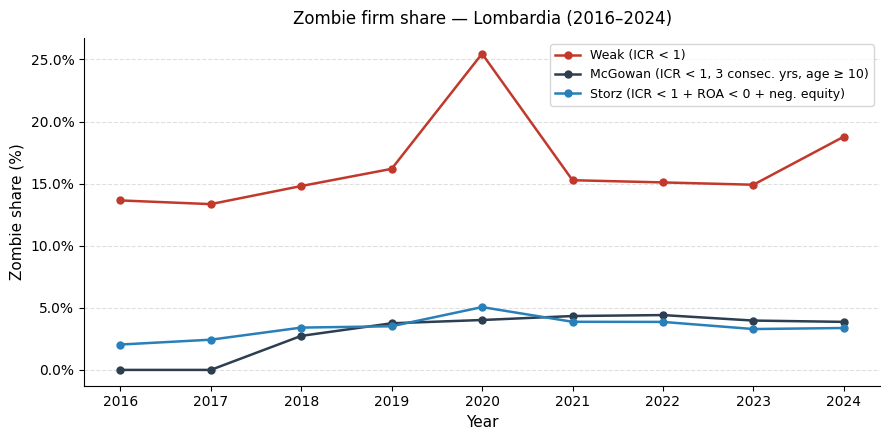

Saved: zombie_share_over_time.png


In [10]:
fig, ax = plt.subplots(figsize=(9, 4.5))

colors = {'zombie_weak': '#c0392b', 'zombie_mcgowan': '#2c3e50', 'zombie_storz': '#2980b9'}
labels = {'zombie_weak': 'Weak (ICR < 1)',
          'zombie_mcgowan': f'McGowan (ICR < 1, {MCGOWAN_CONSEC} consec. yrs, age ≥ {MCGOWAN_MIN_AGE})',
          'zombie_storz': 'Storz (ICR < 1 + ROA < 0 + neg. equity)'}

for zc in zombie_cols:
    ax.plot(summary_df['year'], summary_df[f'{zc}_share'] * 100,
            marker='o', markersize=5, linewidth=1.8,
            color=colors[zc], label=labels[zc])

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Zombie share (%)', fontsize=11)
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f%%'))
ax.set_xticks(summary_df['year'])
ax.legend(fontsize=9, framealpha=0.8)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)
plt.title('Zombie firm share — Lombardia (2016–2024)', fontsize=12, pad=10)
plt.tight_layout()
plt.savefig(BASE_DIR / 'zombie_share_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: zombie_share_over_time.png")


## 5. Zombie share by NACE sector (2022, McGowan)


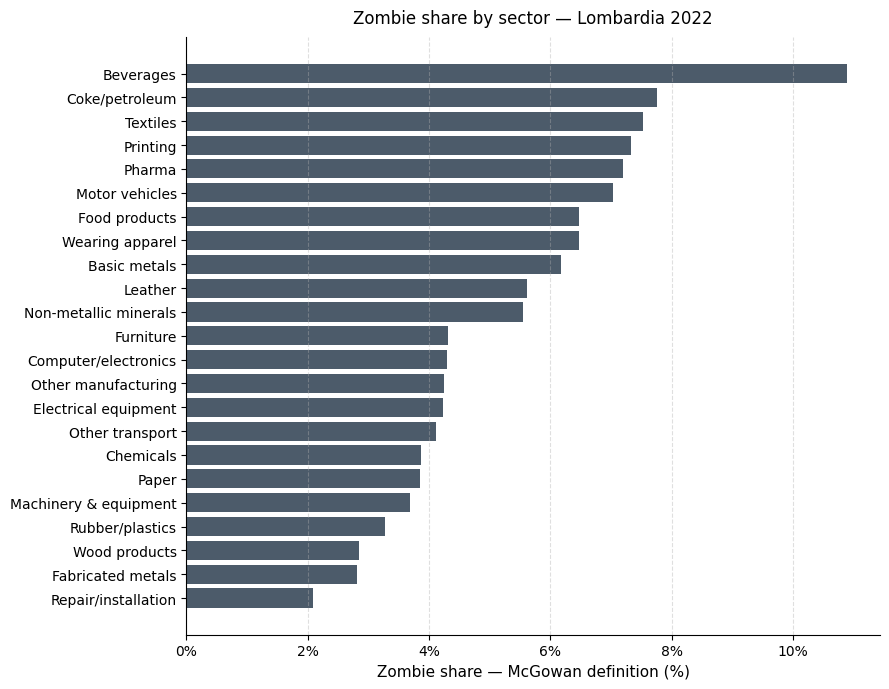

Saved: zombie_share_by_sector_2022.png

                label  n_firms  zombie_share
            Beverages      762         0.109
       Coke/petroleum      129         0.078
             Textiles     2576         0.075
             Printing     1731         0.073
               Pharma      361         0.072
       Motor vehicles     1124         0.070
        Food products     7190         0.065
      Wearing apparel     3619         0.065
         Basic metals     1376         0.062
              Leather     3332         0.056
Non-metallic minerals     2973         0.055
            Furniture     2809         0.043
 Computer/electronics     1814         0.043
  Other manufacturing     2050         0.042
 Electrical equipment     2621         0.042
      Other transport     1142         0.041
            Chemicals     2019         0.039
                Paper     1349         0.039
Machinery & equipment     8612         0.037
      Rubber/plastics     4061         0.033
        Wood pr

In [11]:
NACE_LABELS = {
    10: 'Food products', 11: 'Beverages', 12: 'Tobacco',
    13: 'Textiles', 14: 'Wearing apparel', 15: 'Leather',
    16: 'Wood products', 17: 'Paper', 18: 'Printing',
    19: 'Coke/petroleum', 20: 'Chemicals', 21: 'Pharma',
    22: 'Rubber/plastics', 23: 'Non-metallic minerals',
    24: 'Basic metals', 25: 'Fabricated metals',
    26: 'Computer/electronics', 27: 'Electrical equipment',
    28: 'Machinery & equipment', 29: 'Motor vehicles',
    30: 'Other transport', 31: 'Furniture',
    32: 'Other manufacturing', 33: 'Repair/installation'
}

sub22 = df[(df['year'] == 2022) & df['zombie_mcgowan'].notna()].copy()
nace_stats = (
    sub22.groupby('nace_2digit')
         .agg(n_firms=('bvd_id', 'count'),
              zombie_share=('zombie_mcgowan', 'mean'))
         .reset_index()
)
nace_stats = nace_stats[nace_stats['n_firms'] >= 20]  # only sectors with enough firms
nace_stats['label'] = nace_stats['nace_2digit'].map(NACE_LABELS).fillna(
    nace_stats['nace_2digit'].astype(int).astype(str)
)
nace_stats = nace_stats.sort_values('zombie_share', ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(nace_stats['label'], nace_stats['zombie_share'] * 100,
               color='#2c3e50', alpha=0.85)
ax.set_xlabel('Zombie share — McGowan definition (%)', fontsize=11)
ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f%%'))
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)
plt.title('Zombie share by sector — Lombardia 2022', fontsize=12, pad=10)
plt.tight_layout()
plt.savefig(BASE_DIR / 'zombie_share_by_sector_2022.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: zombie_share_by_sector_2022.png")
print()
print(nace_stats[['label', 'n_firms', 'zombie_share']]
      .sort_values('zombie_share', ascending=False)
      .to_string(index=False, float_format='{:.3f}'.format))


## 6. Zombie entry and exit

How many firms enter zombie status each year, and how many exit? Exit includes both genuine recovery (ICR recovers above 1) and firm dissolution. This is relevant for understanding whether zombie persistence is driven by the stock of existing zombies or continuous new entry.


In [12]:
df_mc = df[df['zombie_mcgowan'].notna()].copy()
df_mc = df_mc.sort_values(['bvd_id', 'year'])

df_mc['zombie_lag'] = df_mc.groupby('bvd_id')['zombie_mcgowan'].shift(1)

# Entry: zombie this year, not zombie last year (or first observed year)
df_mc['zombie_entry'] = ((df_mc['zombie_mcgowan'] == 1) & (df_mc['zombie_lag'] == 0)).astype(float)
# Exit: not zombie this year, zombie last year
df_mc['zombie_exit']  = ((df_mc['zombie_mcgowan'] == 0) & (df_mc['zombie_lag'] == 1)).astype(float)

transitions = df_mc.groupby('year').agg(
    n_zombies  = ('zombie_mcgowan', 'sum'),
    n_entry    = ('zombie_entry', 'sum'),
    n_exit     = ('zombie_exit', 'sum'),
    n_total    = ('zombie_mcgowan', 'count')
).reset_index()
transitions['zombie_share'] = transitions['n_zombies'] / transitions['n_total']

print("Zombie stock, entry and exit by year (McGowan):")
print(transitions.to_string(index=False, float_format='{:.3f}'.format))


Zombie stock, entry and exit by year (McGowan):
 year  n_zombies  n_entry  n_exit  n_total  zombie_share
 2016      0.000    0.000   0.000    74726         0.000
 2017      0.000    0.000   0.000    74726         0.000
 2018   2048.000 2048.000   0.000    74726         0.027
 2019   2806.000  758.000   0.000    74726         0.038
 2020   3003.000  869.000 672.000    74726         0.040
 2021   3242.000  928.000 689.000    74726         0.043
 2022   3300.000  993.000 935.000    74726         0.044
 2023   2969.000  569.000 900.000    74726         0.040
 2024   2891.000  903.000 981.000    74726         0.039


## 7. Save classified panel

In [13]:
# Drop intermediate columns not needed downstream
drop_cols = ['icr_consec_run']
df_out = df.drop(columns=[c for c in drop_cols if c in df.columns])

df_out.to_parquet(OUTPUT_FILE, index=False)
print(f"Saved: {OUTPUT_FILE}")
print(f"  Rows  : {len(df_out):,}")
print(f"  Firms : {df_out['bvd_id'].nunique():,}")
print(f"  Cols  : {df_out.shape[1]}")
print()
print("Zombie columns in output:")
for zc in ['zombie_weak', 'zombie_mcgowan', 'zombie_storz']:
    if zc in df_out.columns:
        share = df_out[df_out['year']==2022][zc].mean()
        print(f"  {zc:<20s}: 2022 share = {share:.1%}")


Saved: /Users/leoss/Desktop/Thesis Replication/output/zombie_panel_classified.parquet
  Rows  : 672,534
  Firms : 74,726
  Cols  : 55

Zombie columns in output:
  zombie_weak         : 2022 share = 15.1%
  zombie_mcgowan      : 2022 share = 4.4%
  zombie_storz        : 2022 share = 3.9%


## Supplementary checks

Cells below implement checks from the literature but do not modify the output parquet. They are diagnostic only — results should be reviewed before finalising the sample.

### Check 1 — Employment representativeness

Compares total employment in the sample to ISTAT aggregate manufacturing employment. ISTAT publishes annual employment in NACE C (manufacturing) in thousands. Update `ISTAT_EMP` with values from https://dati.istat.it/ if needed.

In [14]:
# ISTAT manufacturing employment (thousands) — update from dati.istat.it
# Source: ISTAT, Rilevazione sulle forze di lavoro, NACE C, employees
ISTAT_EMP = {
    2016: 3820, 2017: 3900, 2018: 3960, 2019: 3980,
    2020: 3830, 2021: 3940, 2022: 4020, 2023: 4010, 2024: 3990,
}

sample_emp = (
    df_out[df_out['year'].isin(ISTAT_EMP.keys()) & df_out['employees'].notna()]
    .groupby('year')['employees'].sum() / 1000
)

print('Employment representativeness check:')
print(f"  {'Year':<6} {'Sample (k)':>12} {'ISTAT (k)':>12} {'Coverage':>10}")
for yr in sorted(ISTAT_EMP):
    s = sample_emp.get(yr, np.nan)
    istat = ISTAT_EMP[yr]
    cov = s / istat if not np.isnan(s) else np.nan
    print(f"  {yr:<6} {s:>12,.0f} {istat:>12,} {cov:>9.1%}")
print('\nNote: coverage < 40% in any year warrants restricting that year from analysis.')
print('ISTAT values above are approximate — replace with exact figures from dati.istat.it.')


Employment representativeness check:
  Year     Sample (k)    ISTAT (k)   Coverage
  2016          2,918        3,820     76.4%
  2017          3,058        3,900     78.4%
  2018          3,228        3,960     81.5%
  2019          3,255        3,980     81.8%
  2020          3,291        3,830     85.9%
  2021          3,358        3,940     85.2%
  2022          3,479        4,020     86.5%
  2023          3,492        4,010     87.1%
  2024          3,457        3,990     86.7%

Note: coverage < 40% in any year warrants restricting that year from analysis.
ISTAT values above are approximate — replace with exact figures from dati.istat.it.


### Check 2 — Consolidated accounts duplication

Checks whether any BvD ID appears with both consolidated (C1/C2) and unconsolidated (U1/U2) filings. If so, the consolidated row is a parent-level aggregate that double-counts subsidiaries already in the panel. Reports the share and runs a robustness check showing zombie shares under unconsolidated-only.

In [15]:
# Firms appearing with multiple consolidation codes
consol_per_firm = (
    df_out.groupby('bvd_id')['consolidation_code']
    .apply(lambda s: set(s.dropna()))
)

has_both = consol_per_firm.apply(
    lambda s: bool(s & {'C1','C2'}) and bool(s & {'U1','U2'})
)
n_both = has_both.sum()
print(f'Firms with both consolidated and unconsolidated filings: {n_both:,} '
      f'({n_both/len(has_both):.1%} of sample)')

# Consolidation code distribution
print('\nConsolidation code distribution (2022):')
cc22 = df_out[df_out['year']==2022]['consolidation_code'].value_counts()
for cc, n in cc22.items():
    print(f'  {cc}: {n:,} ({n/cc22.sum():.1%})')

# Zombie shares: full sample vs unconsolidated-only
df_u = df_out[df_out['consolidation_code'].isin(['U1','U2'])].copy()
print(f'\nUnconsolidated-only sample: {df_u["bvd_id"].nunique():,} firms')
print('\nZombie share comparison (2022):')
for zc in ['zombie_weak','zombie_mcgowan','zombie_storz']:
    if zc not in df_out.columns: continue
    full_share = df_out[df_out['year']==2022][zc].mean()
    u_share    = df_u[df_u['year']==2022][zc].mean()
    print(f'  {zc:<20s}: full={full_share:.1%}  unconsolidated-only={u_share:.1%}  '
          f'diff={u_share-full_share:+.2%}')

# Save unconsolidated-only panel as separate file for NB3 robustness
u_out = BASE_DIR / 'zombie_panel_classified_u.parquet'
df_u.to_parquet(u_out, index=False)
print(f'\nSaved unconsolidated-only panel: {u_out}')
print(f'  Firms: {df_u["bvd_id"].nunique():,}  Rows: {len(df_u):,}')


Firms with both consolidated and unconsolidated filings: 0 (0.0% of sample)

Consolidation code distribution (2022):
  U1: 72,413 (96.9%)
  C2: 1,286 (1.7%)
  U2: 921 (1.2%)
  C1: 106 (0.1%)

Unconsolidated-only sample: 73,334 firms

Zombie share comparison (2022):
  zombie_weak         : full=15.1%  unconsolidated-only=15.1%  diff=-0.04%
  zombie_mcgowan      : full=4.4%  unconsolidated-only=4.4%  diff=-0.01%
  zombie_storz        : full=3.9%  unconsolidated-only=3.9%  diff=+0.05%

Saved unconsolidated-only panel: /Users/leoss/Desktop/Thesis Replication/output/zombie_panel_classified_u.parquet
  Firms: 73,334  Rows: 660,006


### Check 8 — Zero-debt (permanently zero financial expenses) firms

Firms with financial expenses = 0 in all observed years can never be classified as zombie under ICR-based definitions. They inflate the non-zombie denominator without being classifiable, potentially deflating the zombie rate.

In [16]:
# Firms with financial expenses = 0 or missing in ALL observed analysis years
fe_by_firm = (
    df_out[df_out['year'].isin(ANALYSIS_YEARS)]
    .groupby('bvd_id')['financial_expenses']
    .apply(lambda s: s.dropna())
)

always_zero = (
    df_out[df_out['year'].isin(ANALYSIS_YEARS)]
    .groupby('bvd_id')['financial_expenses']
    .apply(lambda s: ((s.fillna(0) == 0)).all())
)
n_zero_debt = always_zero.sum()
n_total = always_zero.shape[0]

always_missing = (
    df_out[df_out['year'].isin(ANALYSIS_YEARS)]
    .groupby('bvd_id')['financial_expenses']
    .apply(lambda s: s.isna().all())
)
n_always_missing = always_missing.sum()

print(f'Zero-debt firm analysis (analysis years {ANALYSIS_YEARS[0]}-{ANALYSIS_YEARS[-1]}):')
print(f'  Always zero fin. expenses : {n_zero_debt:,} ({n_zero_debt/n_total:.1%})')
print(f'  Always missing fin. expenses: {n_always_missing:,} ({n_always_missing/n_total:.1%})')
print(f'  Total unclassifiable under ICR: '
      f'{(always_zero | always_missing).sum():,} '
      f'({(always_zero | always_missing).mean():.1%})')

# Check whether zero-debt firms differ systematically in size/sector
snap22 = df_out[df_out['year']==2022].copy()
snap22['zero_debt'] = snap22['bvd_id'].isin(always_zero[always_zero].index)
print('\nZero-debt firms vs others (2022 cross-section):')
print(f'  Median total assets — zero-debt: '
      f'{snap22[snap22.zero_debt]["total_assets"].median():,.0f} k€')
print(f'  Median total assets — with debt: '
      f'{snap22[~snap22.zero_debt]["total_assets"].median():,.0f} k€')
print(f'  Share of zero-debt firms in sample: '
      f'{snap22["zero_debt"].mean():.1%}')


Zero-debt firm analysis (analysis years 2016-2024):
  Always zero fin. expenses : 233 (0.3%)
  Always missing fin. expenses: 0 (0.0%)
  Total unclassifiable under ICR: 233 (0.3%)

Zero-debt firms vs others (2022 cross-section):
  Median total assets — zero-debt: 674 k€
  Median total assets — with debt: 3,237 k€
  Share of zero-debt firms in sample: 0.3%
